## Chipset Dataset - Data preprocessing practicum

### 1. Problem Statement

Can we predict how much power a chipset will consume  given the design specifications-die size, transistor count, make etc?

In [28]:
# import necessary libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [29]:
# Load the dataset
data=pd.read_csv(r'D:\Machine_Learning_Foundations\datasets\chip_dataset (1).csv')
data.head()

,Product,Type,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (GHz),Foundry,Vendor,FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS
0,AMD Athlon 1000,CPU,6/5/00,180,54,120,37,1000.0,NaN,AMD,NaN,NaN,NaN
1,AMD Athlon 1000,CPU,10/31/00,180,54,120,37,1000.0,NaN,AMD,NaN,NaN,NaN
2,AMD Athlon 1100,CPU,8/14/00,180,60,120,37,1100.0,NaN,AMD,NaN,NaN,NaN
3,AMD Athlon 1133,CPU,10/31/00,180,63,120,37,1133.0,NaN,AMD,NaN,NaN,NaN
4,AMD Athlon 1200,CPU,10/31/00,180,66,120,37,1200.0,NaN,AMD,NaN,NaN,NaN


In [30]:
data.tail()

,Product,Type,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (GHz),Foundry,Vendor,FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS
4940,NVIDIA GeForce RTX 3050 6 GB,GPU,NaN,8,80,200,8700,1042.0,Samsung,NVIDIA,6021.0,6021.0,94.08
4941,NVIDIA GeForce RTX 4070 SUPER,GPU,1/8/24,5,220,294,35800,1980.0,TSMC,NVIDIA,35480.0,35480.0,554.40
4942,NVIDIA GeForce RTX 4070 Ti SUPER,GPU,1/8/24,5,285,379,45900,2340.0,TSMC,NVIDIA,44100.0,44100.0,689.00
4943,NVIDIA GeForce RTX 4080 SUPER,GPU,1/8/24,5,320,379,45900,2295.0,TSMC,NVIDIA,52220.0,52220.0,816.00
4944,NVIDIA RTX 5880 Ada Generation,GPU,1/5/24,5,285,609,76300,1155.0,TSMC,NVIDIA,71810.0,71810.0,1122.00


### 2. Data Cleaning

In [31]:
# Step 1- check for data type consistency
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4945 entries, 0 to 4944
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Product                4945 non-null   str    
 1   Type                   4945 non-null   str    
 2   Release Date           4746 non-null   str    
 3   Process Size (nm)      4945 non-null   str    
 4   TDP (W)                4508 non-null   str    
 5   Die Size (mm^2)        4593 non-null   str    
 6   Transistors (million)  4390 non-null   str    
 7   Freq (GHz)             4508 non-null   float64
 8   Foundry                4330 non-null   str    
 9   Vendor                 4945 non-null   str    
 10  FP16 GFLOPS            800 non-null    float64
 11  FP32 GFLOPS            1685 non-null   float64
 12  FP64 GFLOPS            1278 non-null   float64
dtypes: float64(4), str(9)
memory usage: 502.4 KB


We have identified that some numerical features are stored as string- first step is to convert string data type to the appropriate numerical format

In [32]:
data.columns.to_list()

['Product',
 'Type',
 'Release Date',
 'Process Size (nm)',
 'TDP (W)',
 'Die Size (mm^2)',
 'Transistors (million)',
 'Freq (GHz)',
 'Foundry',
 'Vendor',
 'FP16 GFLOPS',
 'FP32 GFLOPS',
 'FP64 GFLOPS']

In [33]:
cols=['Process Size (nm)','TDP (W)','Die Size (mm^2)','Transistors (million)']
data[cols]=data[cols].apply(pd.to_numeric,errors='coerce')

In [34]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4945 entries, 0 to 4944
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Product                4945 non-null   str    
 1   Type                   4945 non-null   str    
 2   Release Date           4746 non-null   str    
 3   Process Size (nm)      4887 non-null   float64
 4   TDP (W)                4054 non-null   float64
 5   Die Size (mm^2)        4229 non-null   float64
 6   Transistors (million)  4139 non-null   float64
 7   Freq (GHz)             4508 non-null   float64
 8   Foundry                4330 non-null   str    
 9   Vendor                 4945 non-null   str    
 10  FP16 GFLOPS            800 non-null    float64
 11  FP32 GFLOPS            1685 non-null   float64
 12  FP64 GFLOPS            1278 non-null   float64
dtypes: float64(8), str(5)
memory usage: 502.4 KB


In [35]:
#Step- Check for missing values
data.isnull().sum()

Product                     0
Type                        0
Release Date              199
Process Size (nm)          58
TDP (W)                   891
Die Size (mm^2)           716
Transistors (million)     806
Freq (GHz)                437
Foundry                   615
Vendor                      0
FP16 GFLOPS              4145
FP32 GFLOPS              3260
FP64 GFLOPS              3667
dtype: int64

<Axes: >

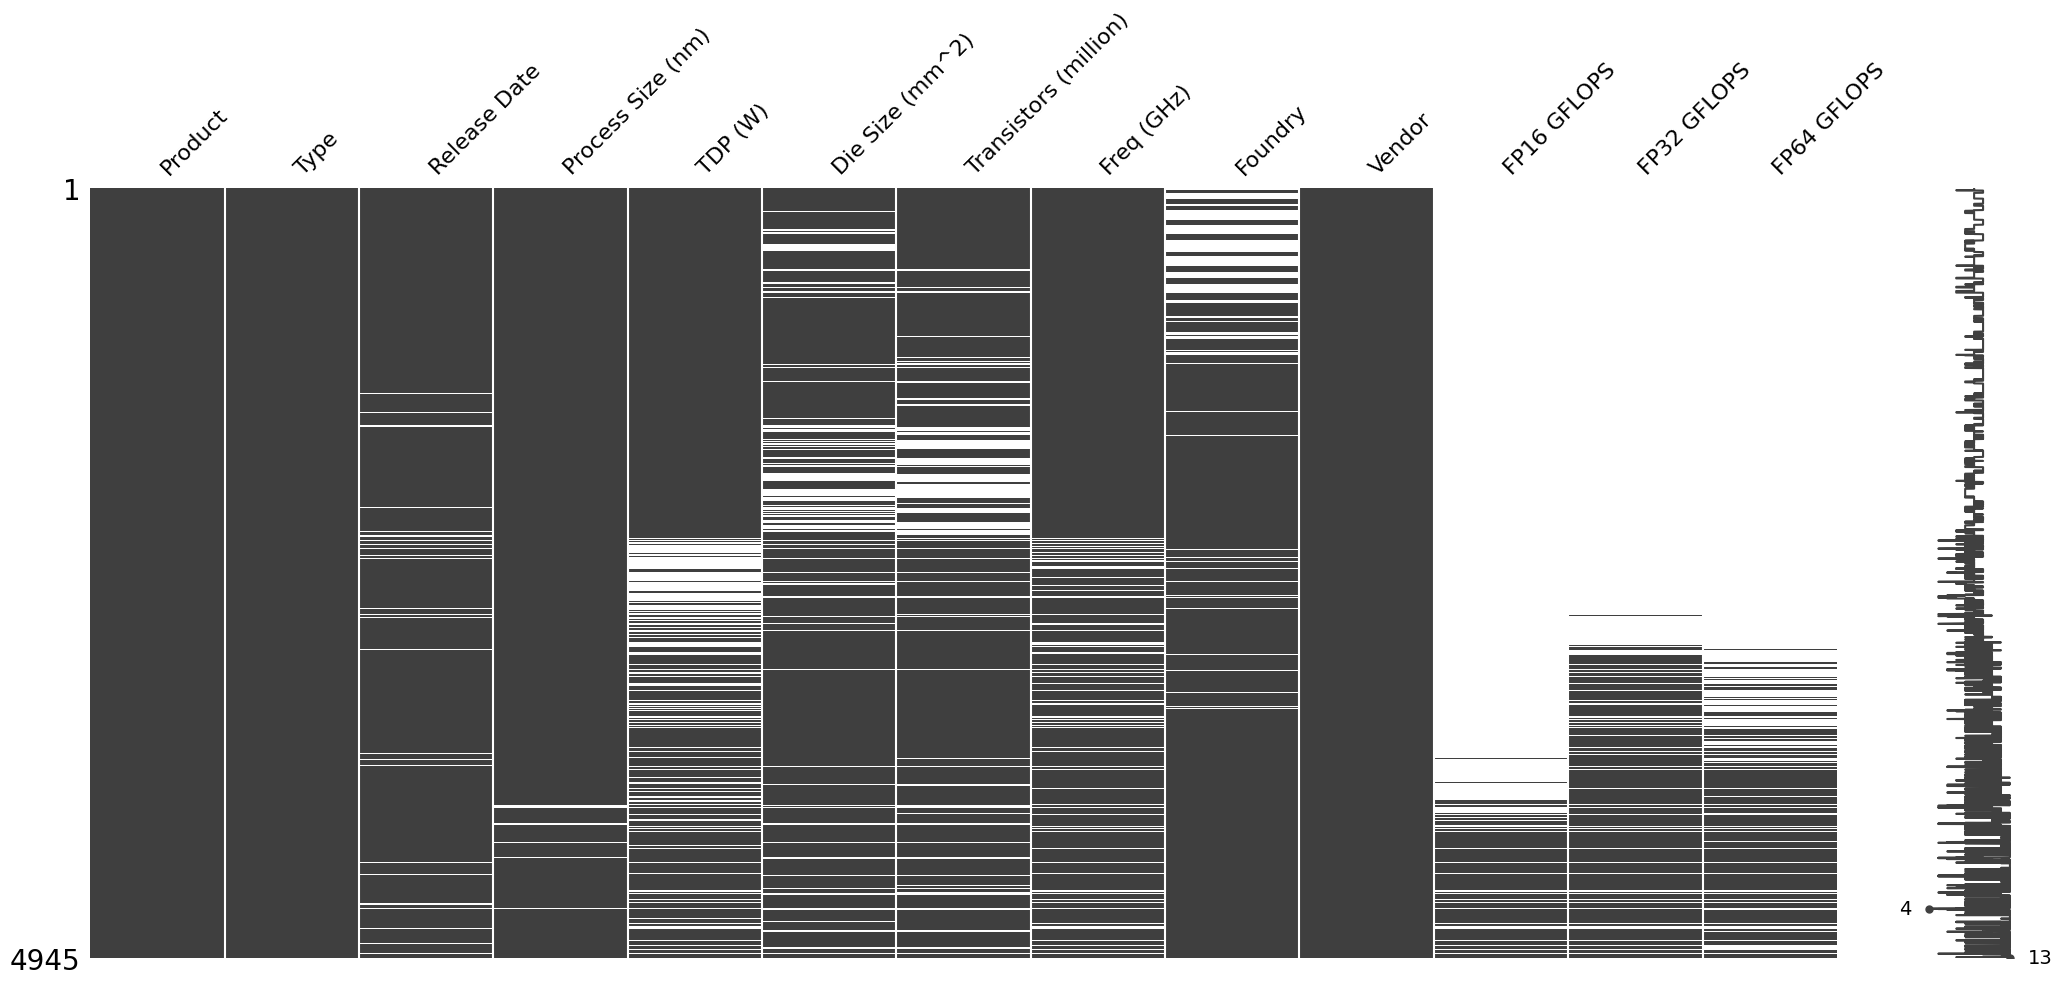

In [36]:
import missingno as mn

mn.matrix(data)

#### Types of Missingness

* Missing Completely at Random
The probability that that data point is missing is totally unrelated to the observed and unobserved data- for example I was filling in a survey and the internet cut off.

* Missing at Random 
The probability that that data point is missing depends on the observed data but not the missing value itself- Men fail to report/answer a question on their mental health status.

* Missing Not at Random
The probability that that data point is misisng depends on the unobserved value - the missing data itself!For example, people with high incomes are less likely to report- survey on incomes.

In [37]:
total_missing=data.isnull().sum().sort_values(ascending=False)
percent=data.isnull().sum().sort_values(ascending=False)/data.isnull().count().sort_values(ascending=False)

missing_df=pd.concat([total_missing,percent],axis=1,keys=['total_missing','percentage_missing'],sort=False)
missing_df.index.name='variable'# set the index name to variable 
missing_df=missing_df[total_missing>0] # only retain those with missing values 
missing_df['percentage_missing']=missing_df['percentage_missing'].map(lambda x:x*100) # convert to percentage 
missing_df

,total_missing,percentage_missing
variable,,
FP16 GFLOPS,4145,83.822042
FP64 GFLOPS,3667,74.155713
FP32 GFLOPS,3260,65.925177
TDP (W),891,18.018200
Transistors (million),806,16.299292
Die Size (mm^2),716,14.479272
Foundry,615,12.436805
Freq (GHz),437,8.837209
Release Date,199,4.024267


In [38]:
data= data.drop(columns=['FP16 GFLOPS', 'FP32 GFLOPS', 'FP64 GFLOPS'])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4945 entries, 0 to 4944
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Product                4945 non-null   str    
 1   Type                   4945 non-null   str    
 2   Release Date           4746 non-null   str    
 3   Process Size (nm)      4887 non-null   float64
 4   TDP (W)                4054 non-null   float64
 5   Die Size (mm^2)        4229 non-null   float64
 6   Transistors (million)  4139 non-null   float64
 7   Freq (GHz)             4508 non-null   float64
 8   Foundry                4330 non-null   str    
 9   Vendor                 4945 non-null   str    
dtypes: float64(5), str(5)
memory usage: 386.5 KB


In [39]:
data.columns.to_list()

['Product',
 'Type',
 'Release Date',
 'Process Size (nm)',
 'TDP (W)',
 'Die Size (mm^2)',
 'Transistors (million)',
 'Freq (GHz)',
 'Foundry',
 'Vendor']

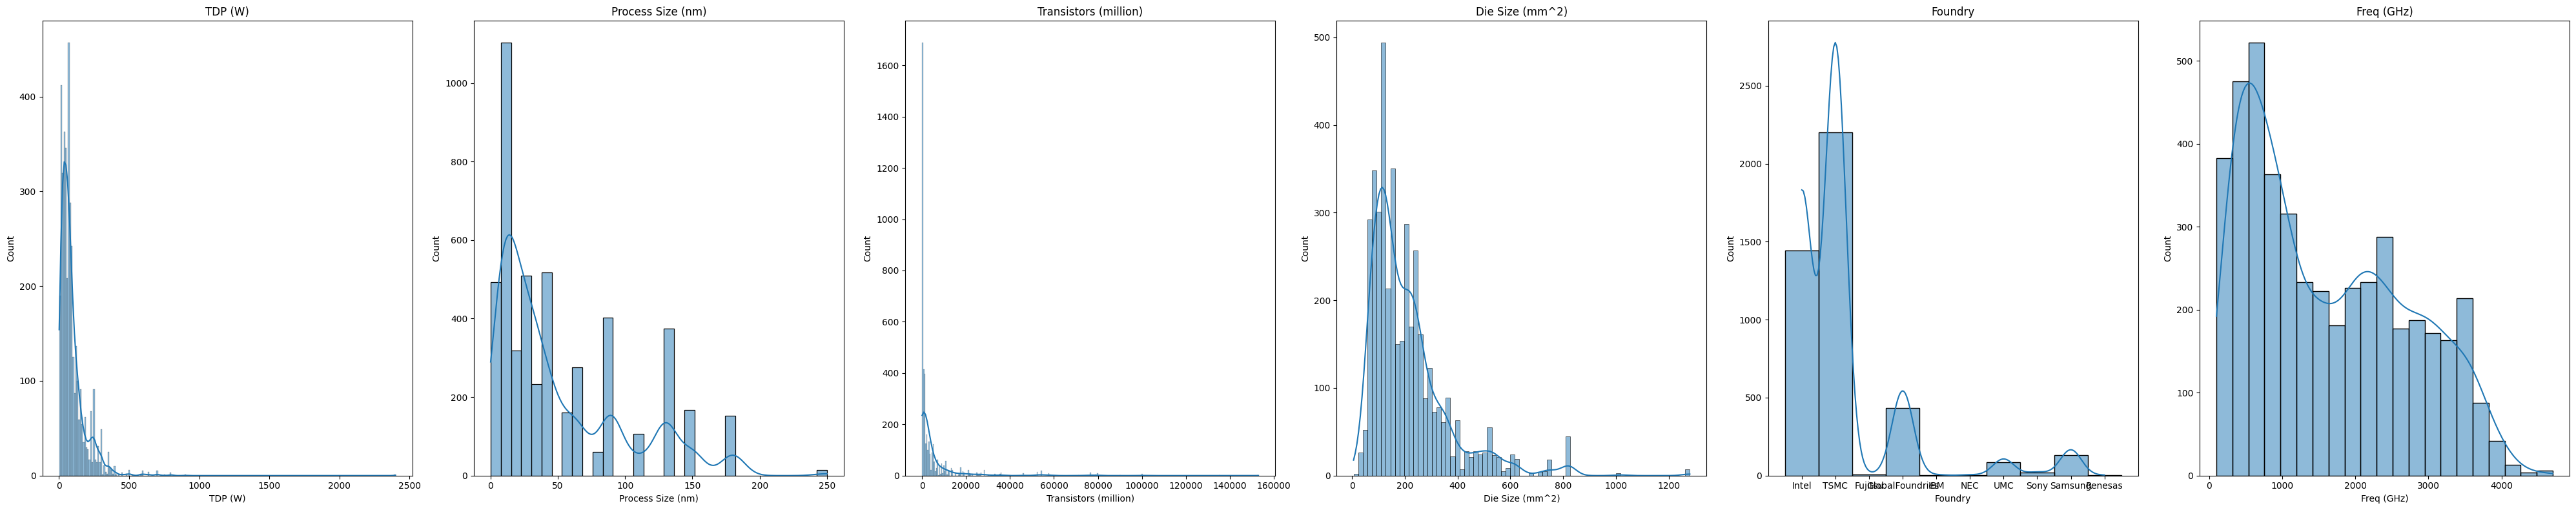

In [40]:
columns_to_plot=['TDP (W)','Process Size (nm)','Transistors (million)',
                 'Die Size (mm^2)','Foundry','Freq (GHz)']
fig = plt.figure(figsize=(40,8))
for i, column in enumerate(columns_to_plot):
    ax = fig.add_subplot(1, 6, i + 1)  
    sns.histplot(data[column],ax=ax,kde=True)
    ax.set_title(column)
plt.tight_layout()
plt.show()

In [41]:
from sklearn.impute import SimpleImputer

imputer=SimpleImputer(strategy='median')
num_df=data.select_dtypes(include=np.number)
data[num_df.columns]=imputer.fit_transform(data[num_df.columns])

In [42]:
#imputing for the categorical columns
cat_df=data.select_dtypes(include='string')
imputer_cat=SimpleImputer(strategy='most_frequent')
data[cat_df.columns]=imputer_cat.fit_transform(data[cat_df.columns])

In [43]:
data.isnull().sum()

Product                  0
Type                     0
Release Date             0
Process Size (nm)        0
TDP (W)                  0
Die Size (mm^2)          0
Transistors (million)    0
Freq (GHz)               0
Foundry                  0
Vendor                   0
dtype: int64

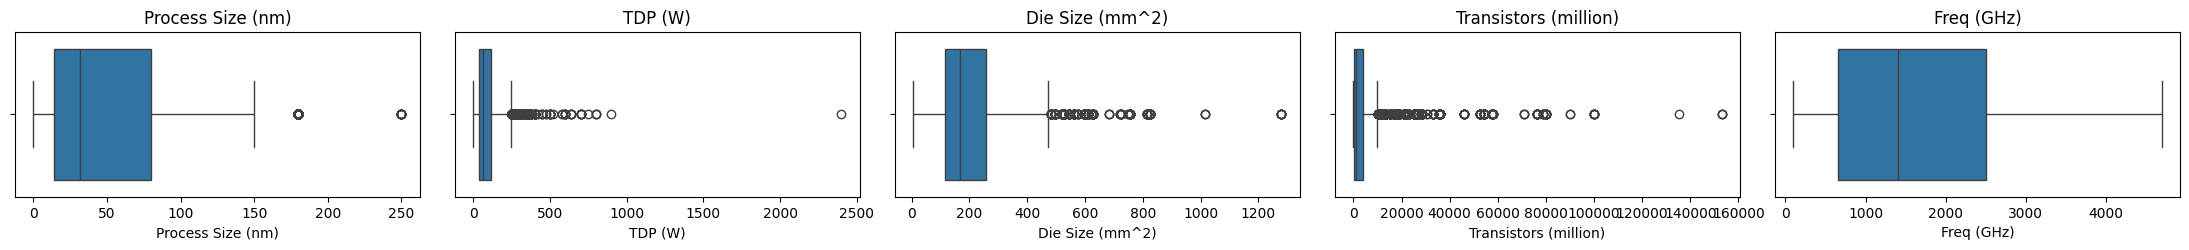

In [44]:
fig = plt.figure(figsize=(22,20))
for i in range(len(num_df.columns)):
    ax=fig.add_subplot(9, 5, i+1)
    sns.boxplot(x=num_df.iloc[:, i],ax=ax)
    ax.set_title(num_df.columns[i])
plt.tight_layout()
plt.show()

In [45]:
#  We also have release date, which is temporal- convert to datetime object
data['Release Date']=pd.to_datetime(data['Release Date'],errors='coerce')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4945 entries, 0 to 4944
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Product                4945 non-null   str           
 1   Type                   4945 non-null   str           
 2   Release Date           4945 non-null   datetime64[us]
 3   Process Size (nm)      4945 non-null   float64       
 4   TDP (W)                4945 non-null   float64       
 5   Die Size (mm^2)        4945 non-null   float64       
 6   Transistors (million)  4945 non-null   float64       
 7   Freq (GHz)             4945 non-null   float64       
 8   Foundry                4945 non-null   str           
 9   Vendor                 4945 non-null   str           
dtypes: datetime64[us](1), float64(5), str(4)
memory usage: 386.5 KB


C:\Users\Wambui\AppData\Local\Temp\ipykernel_19512\21864379.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Release Date']=pd.to_datetime(data['Release Date'],errors='coerce')


### 3. Exploratory Data Analysis (EDA)

In [46]:
data.head()

,Product,Type,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (GHz),Foundry,Vendor
0,AMD Athlon 1000,CPU,2000-06-05,180.0,54.0,120.0,37.0,1000.0,TSMC,AMD
1,AMD Athlon 1000,CPU,2000-10-31,180.0,54.0,120.0,37.0,1000.0,TSMC,AMD
2,AMD Athlon 1100,CPU,2000-08-14,180.0,60.0,120.0,37.0,1100.0,TSMC,AMD
3,AMD Athlon 1133,CPU,2000-10-31,180.0,63.0,120.0,37.0,1133.0,TSMC,AMD
4,AMD Athlon 1200,CPU,2000-10-31,180.0,66.0,120.0,37.0,1200.0,TSMC,AMD


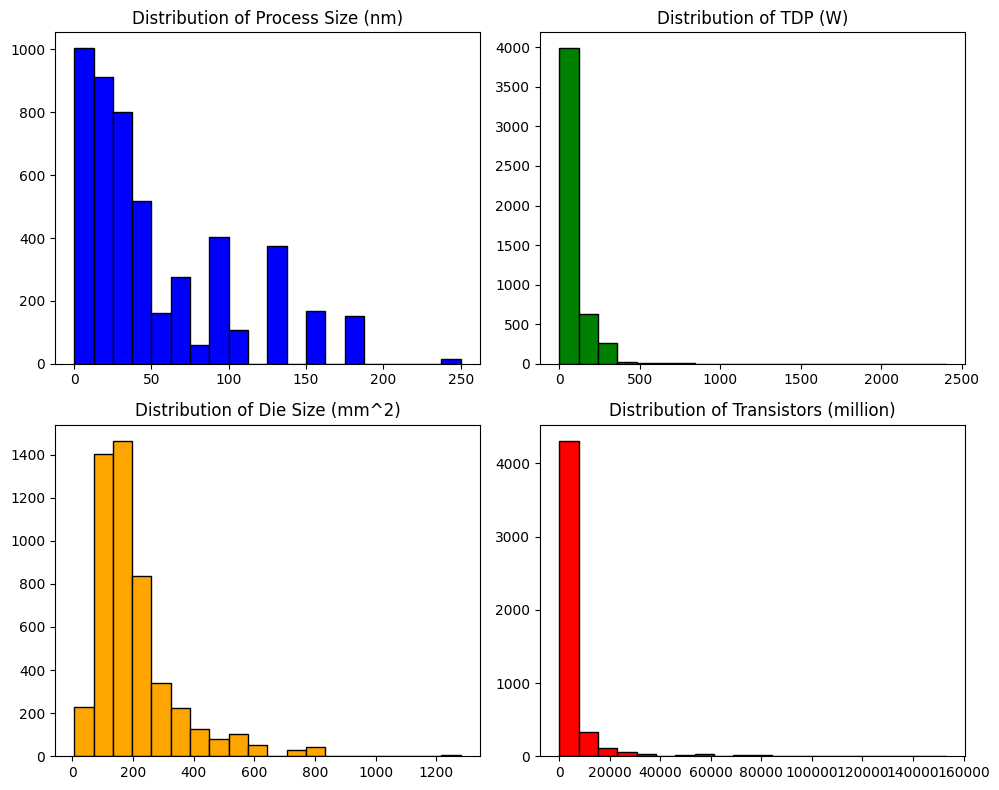

In [47]:
# Distributions of Process size,TDP, die size, transistors

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].hist(data['Process Size (nm)'], bins=20, color='blue', edgecolor='black')
axs[0,0].set_title('Distribution of Process Size (nm)')

axs[0,1].hist(data['TDP (W)'], bins=20, color='green', edgecolor='black')
axs[0,1].set_title('Distribution of TDP (W)')

axs[1,0].hist(data['Die Size (mm^2)'], bins=20, color='orange', edgecolor='black')
axs[1,0].set_title('Distribution of Die Size (mm^2)')   

axs[1,1].hist(data['Transistors (million)'], bins=20, color='red', edgecolor='black')
axs[1,1].set_title('Distribution of Transistors (million)')


plt.tight_layout()
plt.show()

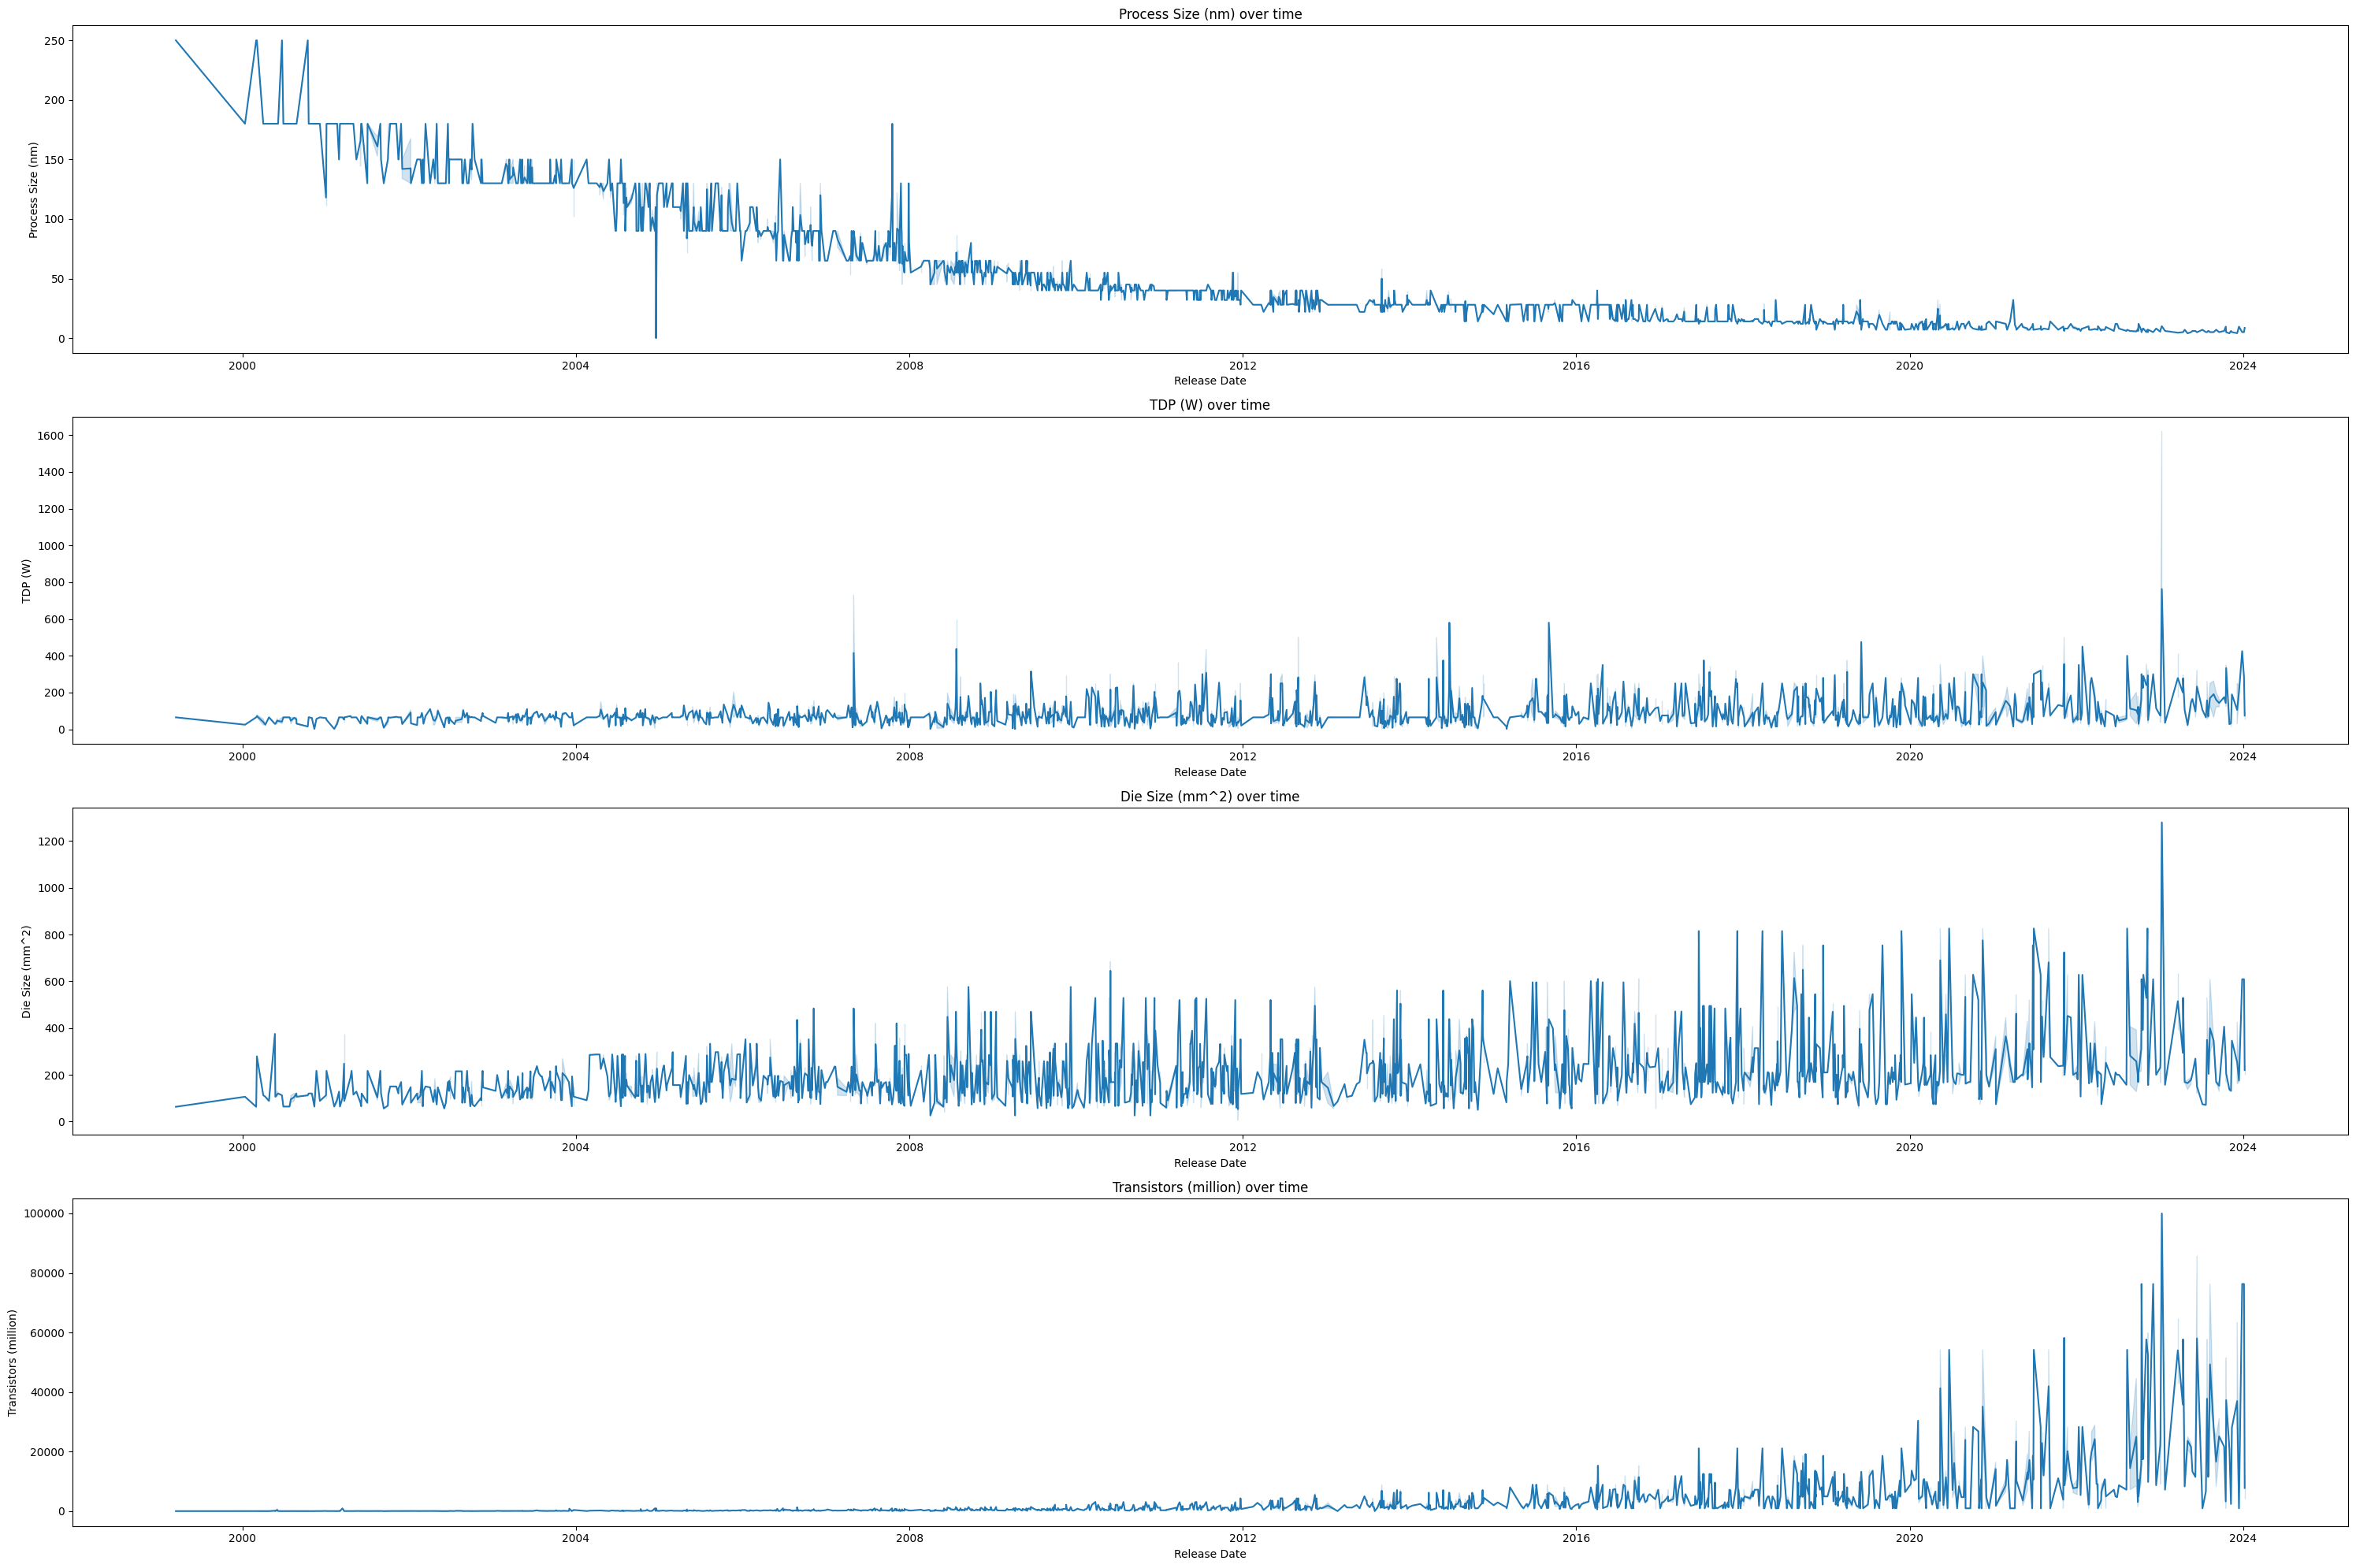

In [48]:
#Let's look at some trends, how have the chipset specifications changed over time

fig, axs = plt.subplots(4,figsize=(30,20))


sns.lineplot(x='Release Date',y='Process Size (nm)',data=data,ax=axs[0])
axs[0].set_title('Process Size (nm) over time')

sns.lineplot(x='Release Date',y='TDP (W)',data=data,ax=axs[1])
axs[1].set_title('TDP (W) over time')

sns.lineplot(x='Release Date',y='Die Size (mm^2)',data=data,ax=axs[2])
axs[2].set_title('Die Size (mm^2) over time')

sns.lineplot(x='Release Date',y='Transistors (million)',data=data,ax=axs[3])
axs[3].set_title('Transistors (million) over time')

plt.tight_layout()
plt.show()

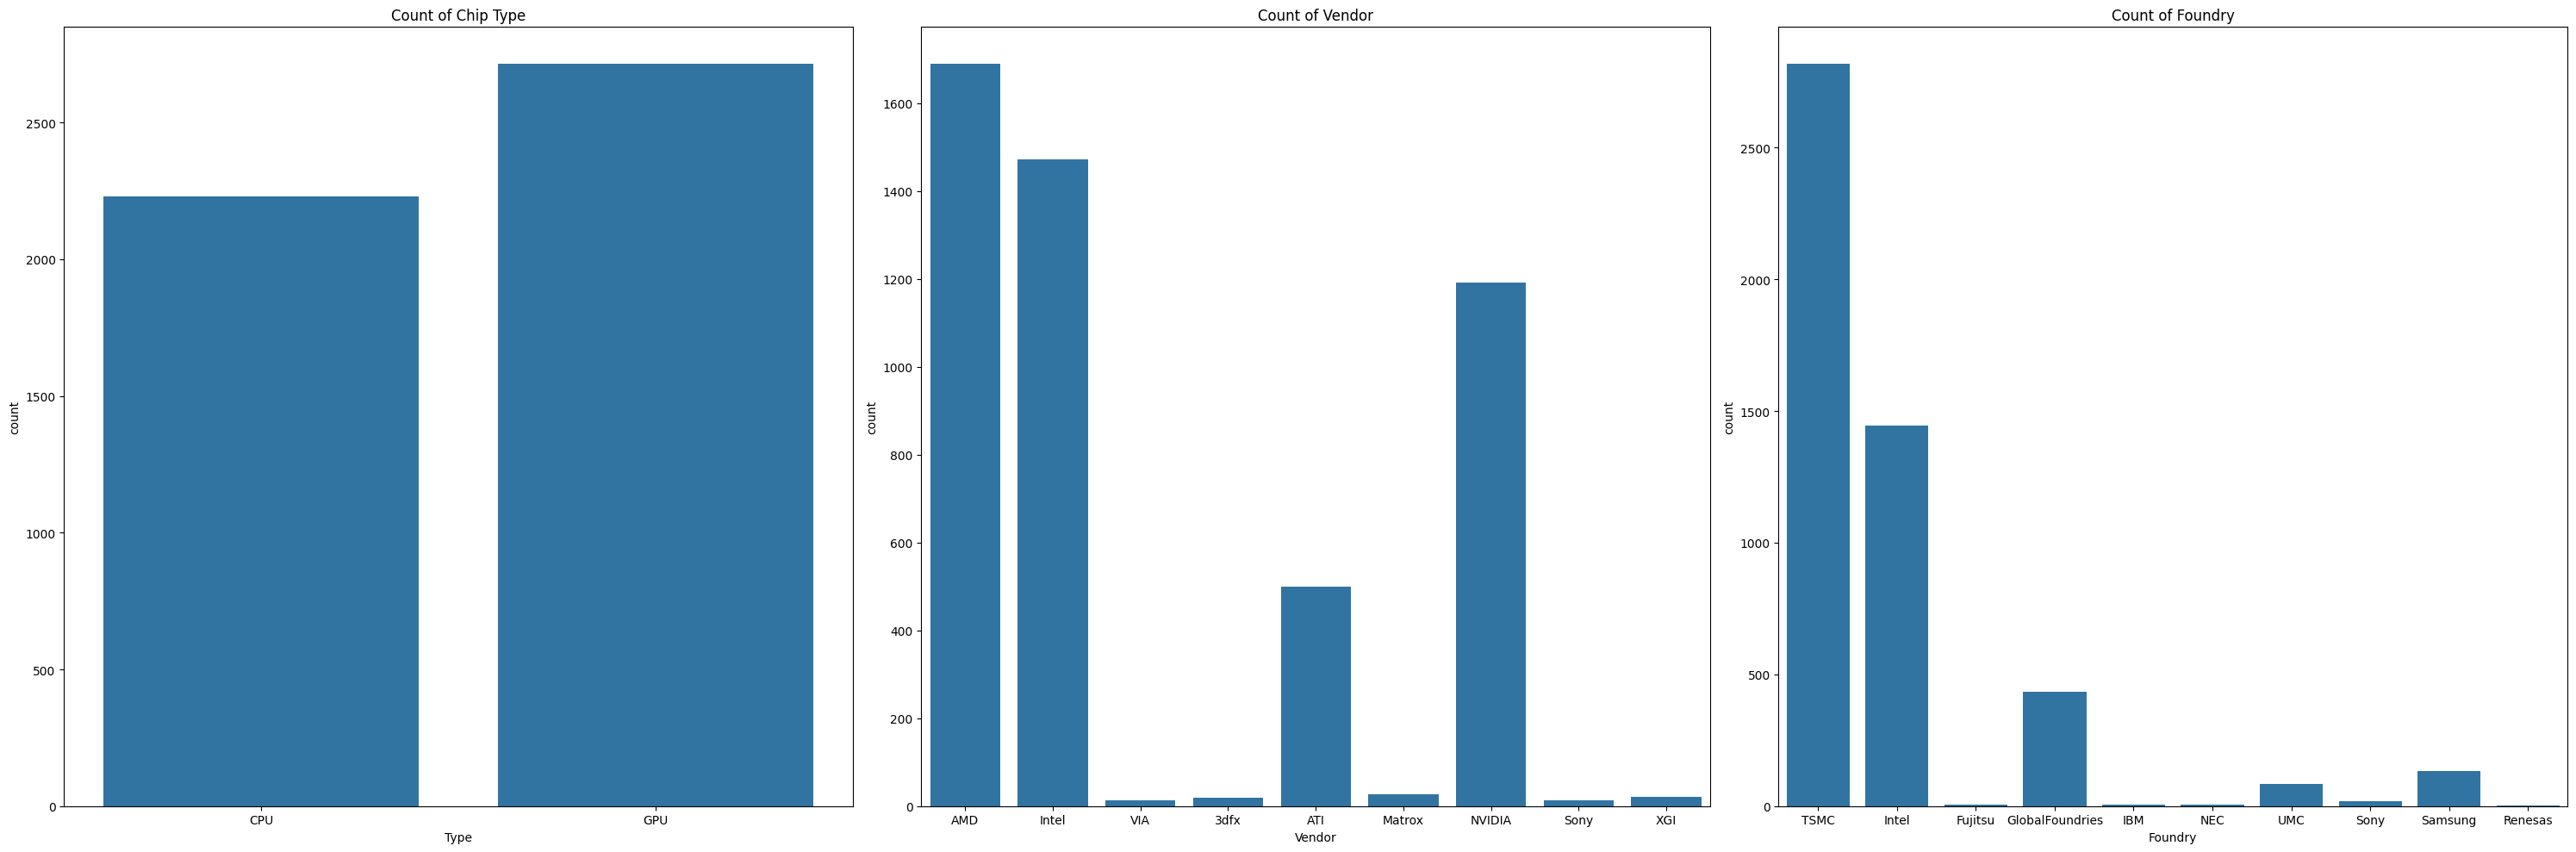

In [49]:
# Then some EDA on the categorical features- type, vendor and foundry...

fig,axs=plt.subplots(1,3,figsize=(30,10))

sns.countplot(x='Type',data=data,ax=axs[0])
axs[0].set_title('Count of Chip Type')   

sns.countplot(x='Vendor',data=data,ax=axs[1])
axs[1].set_title('Count of Vendor')   

sns.countplot(x='Foundry',data=data,ax=axs[2])
axs[2].set_title('Count of Foundry')   

plt.tight_layout()
plt.show()

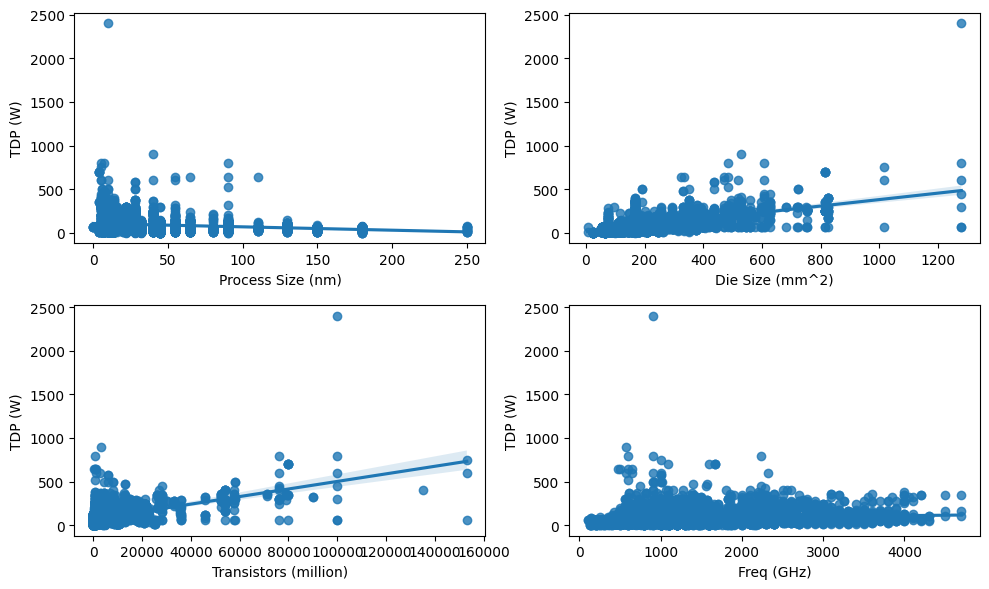

In [50]:
# next, we look at relationships between your input features and your target variable

fig, axs = plt.subplots(2, 2, figsize=(10, 6))

sns.regplot(x='Process Size (nm)',y='TDP (W)',data=data,ax=axs[0,0])
sns.regplot(x='Die Size (mm^2)',y='TDP (W)',data=data,ax=axs[0,1])
sns.regplot(x='Transistors (million)',y='TDP (W)',data=data,ax=axs[1,0])
sns.regplot(x='Freq (GHz)',y='TDP (W)',data=data,ax=axs[1,1])


plt.tight_layout()
plt.show()

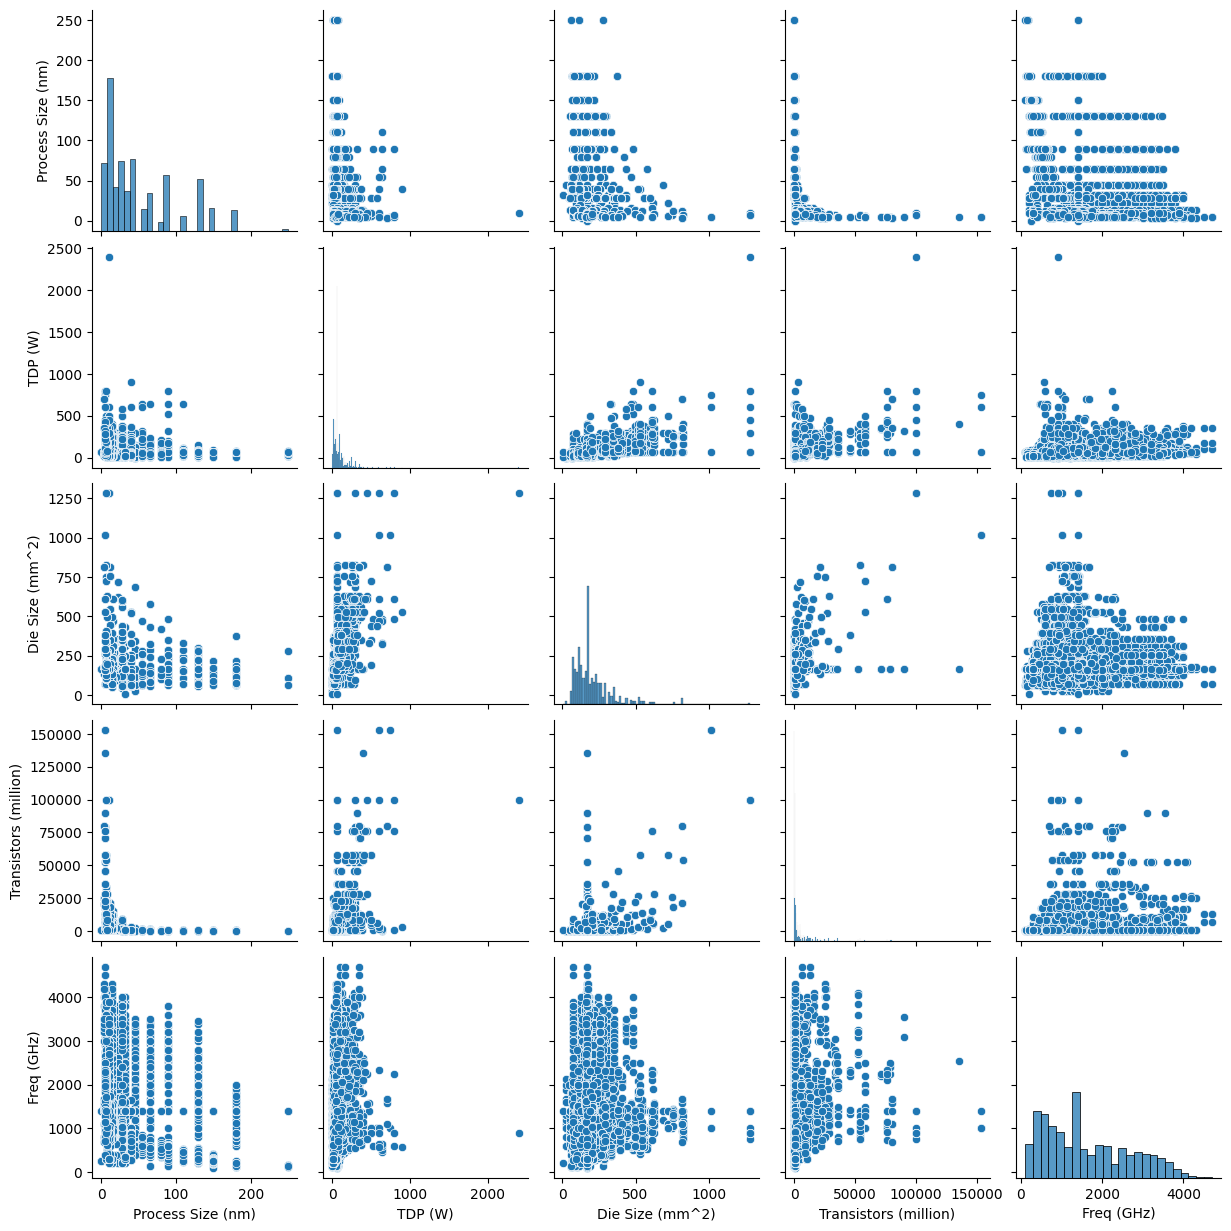

In [51]:
sns.pairplot(data)

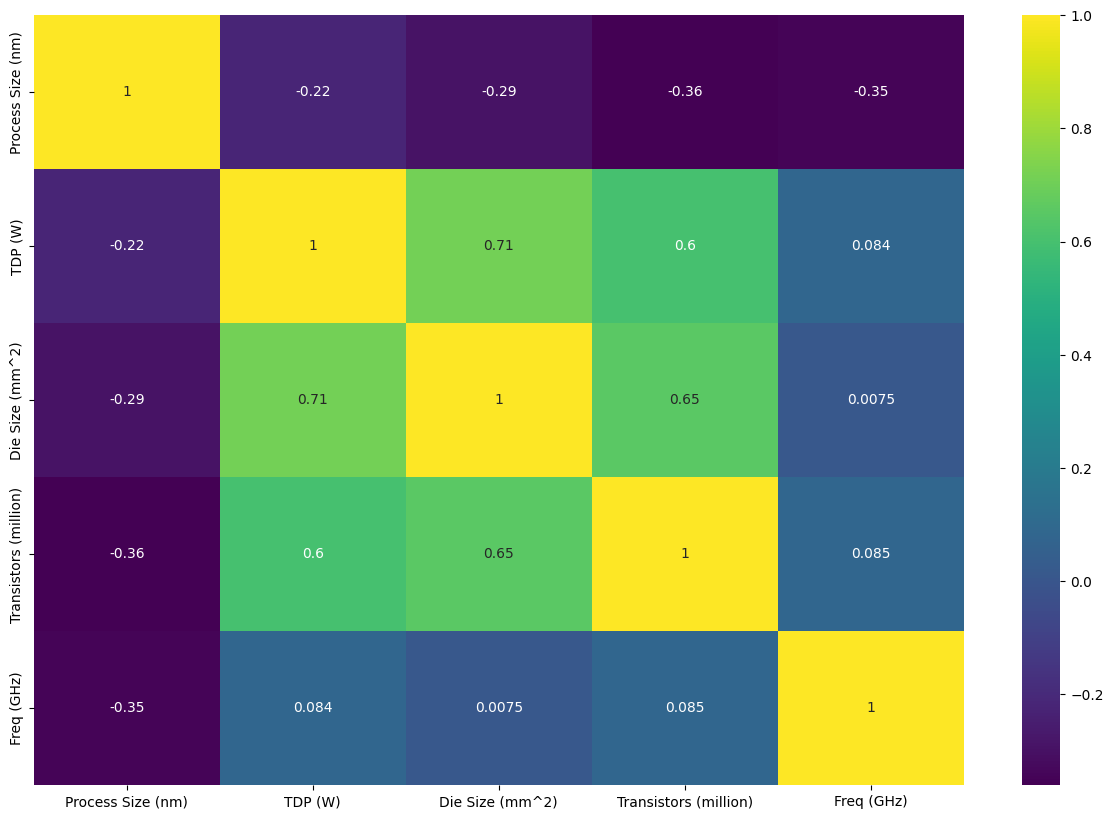

In [52]:
corrmat = num_df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(15,10))
g=sns.heatmap(num_df[top_corr_features].corr(),annot=True,cmap="viridis")

#### Why do we do EDA in ML
1. Context and model interpretation
2. Feature Selection
2. Identify multi-collinearity 
3. Model selection - linear vs. non-linear models

### 4. Data Proprocessing

### Feature Encoding
A data pre-procesisng step where you transform categorical (non-numeric features) into numeric format.

- One hot encoding
- Count/ Frequency encoding
- Label encoding
- Ordinal encoding
- Target encoding

#### Feature Scaling
Data Transformation step, where you transform numerical features into a standardized range.

- Standardization ( z-score normalization/ Standard scaler): transforms your data to have a mean of 0 and standard deviation of 1- use when your data is normally distributed.

- Normalization (min-max Scaler: transforms your data to be betwene min and max- Use when your data is NOT normally distributed.

- Robust scaling/scaler
- MaxAbs Scaling

#### Feature Engineering
Creating NEW features from your input features...

#### Getting your data ready for modelling- introduction to Model Validation
***What is model validation and its importance?***


Model validation tests how well a machine learning model performs on unseen data. Rather than waiting for new data, we use existing data to evaluate its performance, helping us catch issues before real-world deployment.
There are 2 main model validation techniques, which are further broken down into 12 and each are used depending on the specific machine learning challenge.

![image.webp](..\assets\15eu6sk1xVs3aPGRi6TQW8Q-2048x1326.webp)

#### Machine Learning concepts: The Varaince Bias Tradeoff
--->Refer to illustration to build intuition(Excalidraw)

